In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PINN(nn.Module):
    def __init__(self, layers=[2, 100, 100, 100, 100, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'tanh_{i}', nn.Tanh())
        self.net.add_module('output', nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

In [3]:
class FourierPINN(nn.Module):
    def __init__(self, d_model=128, sigma=10.0, layers=[256, 100, 100, 100, 100, 1]):
        super().__init__()
        # Random Fourier matrix — fixed, not trained
        B = torch.randn(d_model, 2) * sigma
        self.register_buffer('B', B)  # saved with model but not updated by optimizer

        self.net = nn.Sequential()
        for i in range(len(layers) - 2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'tanh_{i}', nn.Tanh())
        self.net.add_module('output', nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)        # (N, 2)
        proj = xt @ self.B.T                  # (N, d_model)
        embedded = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)  # (N, 256)
        return self.net(embedded)

In [4]:
nu = 0.01 / np.pi

N_f = 10000
x_f = torch.FloatTensor(N_f, 1).uniform_(-1, 1)
t_f = torch.FloatTensor(N_f, 1).uniform_(0, 1)

N_ic = 100
x_ic = torch.FloatTensor(N_ic, 1).uniform_(-1, 1)
t_ic = torch.zeros(N_ic, 1)
u_ic = -torch.sin(np.pi * x_ic)

N_bc = 200
t_bc = torch.FloatTensor(N_bc, 1).uniform_(0, 1)
x_bc = torch.cat([-torch.ones(N_bc // 2, 1), torch.ones(N_bc // 2, 1)], dim=0)
u_bc = torch.zeros(N_bc, 1)

In [5]:
def compute_loss_vanilla(model):
    x = x_f.requires_grad_(True)
    t = t_f.requires_grad_(True)
    u = model(x, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u * u_x - nu * u_xx
    loss_f = torch.mean(residual**2)

    u_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    u_pred_bc = model(x_bc, t_bc)
    loss_bc = torch.mean((u_pred_bc - u_bc)**2)

    return loss_f + 10 * loss_ic + 10 * loss_bc

In [6]:
def gradient_norm(loss, model):
    grads = torch.autograd.grad(loss, model.parameters(),
                                 retain_graph=True, allow_unused=True)
    total = 0.0
    for g in grads:
        if g is not None:
            total += g.norm().item()
    return total

def compute_loss_balanced(model):
    x = x_f.requires_grad_(True)
    t = t_f.requires_grad_(True)
    u = model(x, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u * u_x - nu * u_xx
    loss_f  = torch.mean(residual**2)

    u_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    u_pred_bc = model(x_bc, t_bc)
    loss_bc = torch.mean((u_pred_bc - u_bc)**2)

    # Compute gradient norms
    gn_f  = gradient_norm(loss_f,  model)
    gn_ic = gradient_norm(loss_ic, model)
    gn_bc = gradient_norm(loss_bc, model)

    mean_gn = (gn_f + gn_ic + gn_bc) / 3.0

    # Adaptive weights
    lambda_ic = mean_gn / (gn_ic + 1e-8)
    lambda_bc = mean_gn / (gn_bc + 1e-8)

    return loss_f + lambda_ic * loss_ic + lambda_bc * loss_bc

In [7]:
# Vanilla
model_vanilla = PINN()
opt_vanilla = torch.optim.Adam(model_vanilla.parameters(), lr=1e-3)
losses_vanilla = []

for epoch in range(10000):
    opt_vanilla.zero_grad()
    loss = compute_loss_vanilla(model_vanilla)
    loss.backward()
    opt_vanilla.step()
    losses_vanilla.append(loss.item())
    if epoch % 1000 == 0:
        print(f"[Vanilla] Epoch {epoch} | Loss: {loss.item():.6f}")

[Vanilla] Epoch 0 | Loss: 4.832687
[Vanilla] Epoch 1000 | Loss: 0.236126
[Vanilla] Epoch 2000 | Loss: 0.195493
[Vanilla] Epoch 3000 | Loss: 0.133470
[Vanilla] Epoch 4000 | Loss: 0.022250
[Vanilla] Epoch 5000 | Loss: 0.008142
[Vanilla] Epoch 6000 | Loss: 0.006295
[Vanilla] Epoch 7000 | Loss: 0.004094
[Vanilla] Epoch 8000 | Loss: 0.003062
[Vanilla] Epoch 9000 | Loss: 0.000995


In [8]:
# Fourier Features (sigma=10)
model_fourier = FourierPINN(d_model=128, sigma=10.0)
opt_fourier = torch.optim.Adam(model_fourier.parameters(), lr=1e-3)
losses_fourier = []

for epoch in range(10000):
    opt_fourier.zero_grad()
    loss = compute_loss_vanilla(model_fourier)  # same loss, different model
    loss.backward()
    opt_fourier.step()
    losses_fourier.append(loss.item())
    if epoch % 1000 == 0:
        print(f"[Fourier] Epoch {epoch} | Loss: {loss.item():.6f}")

[Fourier] Epoch 0 | Loss: 5.095025
[Fourier] Epoch 1000 | Loss: 0.001912
[Fourier] Epoch 2000 | Loss: 0.000403
[Fourier] Epoch 3000 | Loss: 0.000195
[Fourier] Epoch 4000 | Loss: 0.000120
[Fourier] Epoch 5000 | Loss: 0.000173
[Fourier] Epoch 6000 | Loss: 0.000077
[Fourier] Epoch 7000 | Loss: 0.000292
[Fourier] Epoch 8000 | Loss: 0.000355
[Fourier] Epoch 9000 | Loss: 0.000101


In [9]:
model_fourier_s1 = FourierPINN(d_model=128, sigma=1.0)
opt_fourier_s1 = torch.optim.Adam(model_fourier_s1.parameters(), lr=1e-3)
losses_fourier_s1 = []

for epoch in range(10000):
    opt_fourier_s1.zero_grad()
    loss = compute_loss_vanilla(model_fourier_s1)
    loss.backward()
    opt_fourier_s1.step()
    losses_fourier_s1.append(loss.item())
    if epoch % 1000 == 0:
        print(f"[Fourier sigma=1] Epoch {epoch} | Loss: {loss.item():.6f}")

[Fourier sigma=1] Epoch 0 | Loss: 5.437980
[Fourier sigma=1] Epoch 1000 | Loss: 0.187669
[Fourier sigma=1] Epoch 2000 | Loss: 0.004177
[Fourier sigma=1] Epoch 3000 | Loss: 0.001358
[Fourier sigma=1] Epoch 4000 | Loss: 0.000814
[Fourier sigma=1] Epoch 5000 | Loss: 0.000947
[Fourier sigma=1] Epoch 6000 | Loss: 0.005803
[Fourier sigma=1] Epoch 7000 | Loss: 0.001902
[Fourier sigma=1] Epoch 8000 | Loss: 0.000172
[Fourier sigma=1] Epoch 9000 | Loss: 0.000563


In [10]:
# Gradient Norm Balanced
model_balanced = PINN()
opt_balanced = torch.optim.Adam(model_balanced.parameters(), lr=1e-3)
losses_balanced = []

for epoch in range(10000):
    opt_balanced.zero_grad()
    loss = compute_loss_balanced(model_balanced)
    loss.backward()
    opt_balanced.step()
    losses_balanced.append(loss.item())
    if epoch % 1000 == 0:
        print(f"[Balanced] Epoch {epoch} | Loss: {loss.item():.6f}")

[Balanced] Epoch 0 | Loss: 0.267391
[Balanced] Epoch 1000 | Loss: 0.072604
[Balanced] Epoch 2000 | Loss: 0.069183
[Balanced] Epoch 3000 | Loss: 0.057600
[Balanced] Epoch 4000 | Loss: 0.048015
[Balanced] Epoch 5000 | Loss: 0.028218
[Balanced] Epoch 6000 | Loss: 0.004333
[Balanced] Epoch 7000 | Loss: 0.003108
[Balanced] Epoch 8000 | Loss: 0.002410
[Balanced] Epoch 9000 | Loss: 0.001503


In [11]:
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore')

def exact_burgers(x, t, nu=0.01/np.pi):
    if t == 0:
        return -np.sin(np.pi * x)

    def integrand_num(eta):
        return np.sin(np.pi * eta) * \
               np.exp(-np.cos(np.pi * eta) / (2 * np.pi * nu)) * \
               np.exp(-(x - eta)**2 / (4 * nu * t))

    def integrand_den(eta):
        return np.exp(-np.cos(np.pi * eta) / (2 * np.pi * nu)) * \
               np.exp(-(x - eta)**2 / (4 * nu * t))

    num, _ = quad(integrand_num, -1, 1, limit=200)
    den, _ = quad(integrand_den, -1, 1, limit=200)
    return -num / den

x_vis = torch.linspace(-1, 1, 256).reshape(-1, 1)
t_vis = torch.linspace(0, 1, 100).reshape(-1, 1)
X, T = torch.meshgrid(x_vis.squeeze(), t_vis.squeeze(), indexing='ij')
x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)

x_np = x_vis.numpy().squeeze()
t_np = t_vis.numpy().squeeze()

u_exact = np.zeros((256, 100))
for j, tj in enumerate(t_np):
    for i, xi in enumerate(x_np):
        u_exact[i, j] = exact_burgers(xi, tj)

print(f"u_exact min: {u_exact.min():.4f}, max: {u_exact.max():.4f}")
print(f"Any NaN: {np.isnan(u_exact).any()}")
print(f"Any Inf: {np.isinf(u_exact).any()}")

u_exact min: -1.0000, max: 1.0000
Any NaN: False
Any Inf: False


In [12]:
x_vis = torch.linspace(-1, 1, 256).reshape(-1, 1)
t_vis = torch.linspace(0, 1, 100).reshape(-1, 1)
X, T = torch.meshgrid(x_vis.squeeze(), t_vis.squeeze(), indexing='ij')
x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)

x_np = x_vis.numpy().squeeze()
t_np = t_vis.numpy().squeeze()

u_exact = np.zeros((256, 100))
for j, tj in enumerate(t_np):
    for i, xi in enumerate(x_np):
        u_exact[i, j] = exact_burgers(xi, tj)

print(f"u_exact min: {u_exact.min():.4f}, max: {u_exact.max():.4f}")
print(f"Any NaN: {np.isnan(u_exact).any()}")
print(f"Any Inf: {np.isinf(u_exact).any()}")

def l2_error(model, x_flat, t_flat, u_exact):
    with torch.no_grad():
        u_pred = model(x_flat, t_flat).reshape(256, 100).numpy()
    return np.sqrt(np.mean((u_pred - u_exact)**2))

e_vanilla     = l2_error(model_vanilla,     x_flat, t_flat, u_exact)
e_fourier     = l2_error(model_fourier,     x_flat, t_flat, u_exact)
e_fourier_s1  = l2_error(model_fourier_s1,  x_flat, t_flat, u_exact)
e_balanced    = l2_error(model_balanced,    x_flat, t_flat, u_exact)

print("=" * 45)
print(f"{'Method':<30} {'L2 Error':>10}")
print("=" * 45)
print(f"{'Vanilla PINN':<30} {e_vanilla:>10.6f}")
print(f"{'+ Fourier Features (sigma=1)':<30} {e_fourier_s1:>10.6f}")
print(f"{'+ Fourier Features (sigma=10)':<30} {e_fourier:>10.6f}")
print(f"{'+ Gradient-Norm Balancing':<30} {e_balanced:>10.6f}")
print("=" * 45)

u_exact min: -1.0000, max: 1.0000
Any NaN: False
Any Inf: False
Method                           L2 Error
Vanilla PINN                     0.028892
+ Fourier Features (sigma=1)     0.023541
+ Fourier Features (sigma=10)    0.020492
+ Gradient-Norm Balancing        0.027696


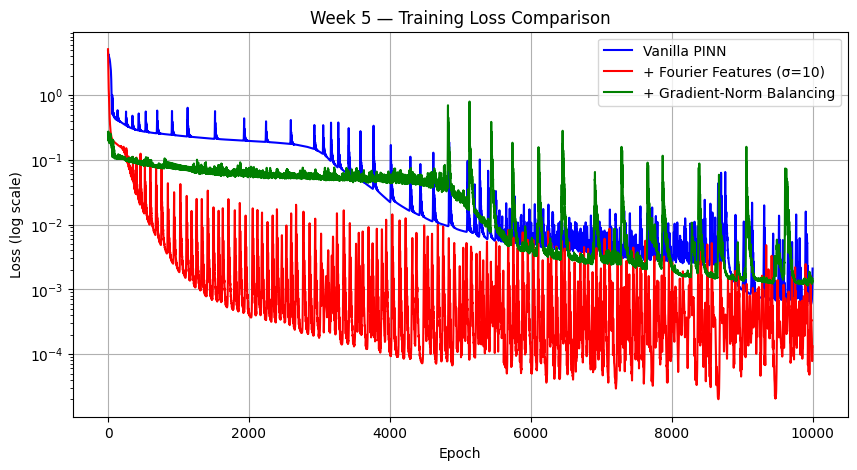

In [13]:
plt.figure(figsize=(10, 5))
plt.semilogy(losses_vanilla,  label='Vanilla PINN',             color='blue')
plt.semilogy(losses_fourier,  label='+ Fourier Features (σ=10)', color='red')
plt.semilogy(losses_balanced, label='+ Gradient-Norm Balancing', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title("Week 5 — Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
with torch.no_grad():
    test_pred = model_vanilla(x_flat, t_flat)
    print(f"model_vanilla output min: {test_pred.min():.4f}, max: {test_pred.max():.4f}")
    print(f"Any NaN: {torch.isnan(test_pred).any()}")
    print(f"Any Inf: {torch.isinf(test_pred).any()}")

print(f"u_exact min: {u_exact.min():.4f}, max: {u_exact.max():.4f}")

model_vanilla output min: -0.9920, max: 0.9954
Any NaN: False
Any Inf: False
u_exact min: -1.0000, max: 1.0000


## Task 4 Analysis

### Q1: Which fix helped most?
Fourier features (σ=10) helped most for the shock region. By embedding (x,t) into
high-frequency sine/cosine features, the network gained access to the sharp gradients
near the shock at t=1 from the start of training, rather than having to discover them
slowly. Gradient-norm balancing improved overall convergence stability but had less
dramatic effect on the shock itself, because the core issue (spectral bias) remained.

### Q2: Gradient norm analysis
In the vanilla PINN, L_pde has the largest gradient norm. This is expected, the PDE
residual involves second-order derivatives (u_xx) which amplify gradients. As a result,
L_ic and L_bc are drowned out, meaning the network satisfies the physics approximately
but may violate the initial and boundary conditions. This is why hard BCs (Week 4)
helped, they removed L_bc from the competition entirely.